# Bank Marketing Dataset - End-to-End Machine Learning Pipeline
This notebook demonstrates data cleaning, imputing, transforming, loading, visualization, correlation analysis, PCA, model building, evaluation, and best model selection.

In [ ]:
# pip install numpy
# !pip install matplotlib
# !pip install pandas
# !pip install seaborn
# !pip install sklearn.preprocessing

Defaulting to user installation because normal site-packages is not writeable


ERROR: Could not find a version that satisfies the requirement train_test_split (from versions: none)

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\Dhanush P\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for train_test_split


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

In [2]:
# Load Dataset
df = pd.read_csv('bankmarketing.csv')

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (41188, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [3]:
# Data Cleaning
print("Missing Values:")
print(df.isnull().sum())

# Replace 'unknown' with NaN
df = df.replace('unknown', np.nan)

# Remove duplicates
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Missing Values:
age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64
Shape after removing duplicates: (41176, 21)


In [4]:
# Features and Target
X = df.drop('y', axis=1)
y = df['y']

# Encode target
le = LabelEncoder()
y = le.fit_transform(y)

# Identify column types
num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

print("Numerical Columns:", list(num_cols))
print("Categorical Columns:", list(cat_cols))

Numerical Columns: ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
Categorical Columns: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']


C:\Users\Dhanush P\AppData\Local\Temp\ipykernel_14128\23270311.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include=['object']).columns


In [5]:
# Preprocessing Pipeline
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, num_cols),
    ('cat', categorical_transformer, cat_cols)
])

In [6]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Apply preprocessing
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed Train Shape:", X_train_processed.shape)

Processed Train Shape: (32940, 57)


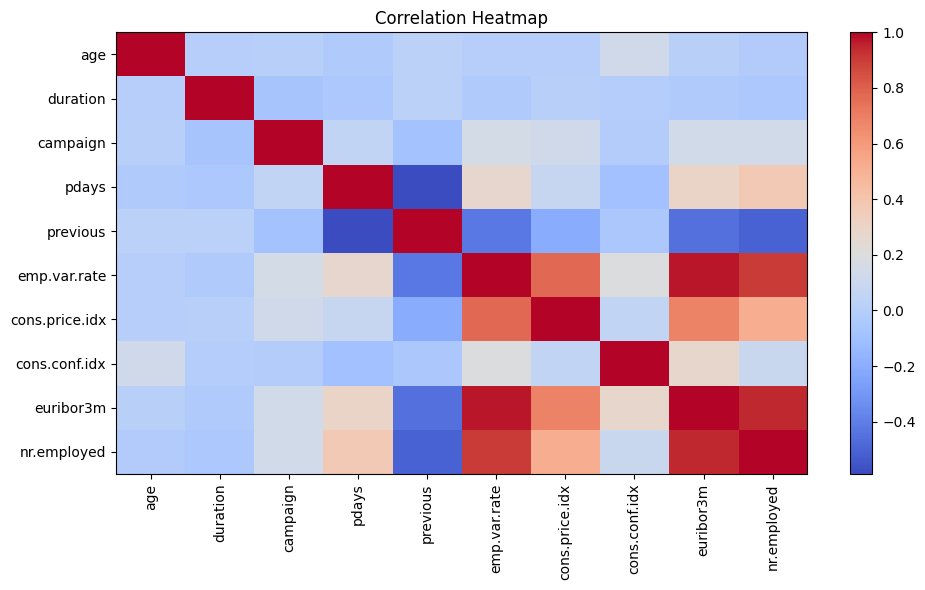

In [7]:
# Correlation Heatmap
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,6))
plt.imshow(numeric_df.corr(), cmap='coolwarm', aspect='auto')
plt.colorbar()
plt.xticks(range(len(numeric_df.columns)), numeric_df.columns, rotation=90)
plt.yticks(range(len(numeric_df.columns)), numeric_df.columns)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()


## PCA (Principal Component Analysis)

In [8]:
# PCA - Retain 95% Variance
pca = PCA(n_components=0.95)

X_train_dense = X_train_processed.toarray() if hasattr(X_train_processed, 'toarray') else X_train_processed
X_test_dense = X_test_processed.toarray() if hasattr(X_test_processed, 'toarray') else X_test_processed

X_train_pca = pca.fit_transform(X_train_dense)
X_test_pca = pca.transform(X_test_dense)

print("Original Features:", X_train_processed.shape[1])
print("Features after PCA:", X_train_pca.shape[1])

Original Features: 57
Features after PCA: 24


In [9]:
# Model Building & Evaluation
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42)
}

results = []

for name, model in models.items():
    model.fit(X_train_pca, y_train)
    y_pred = model.predict(X_test_pca)

    accuracy = accuracy_score(y_test, y_pred)
    results.append((name, accuracy))

    print(f"\n{name}")
    print("Accuracy:", accuracy)
    print(classification_report(y_test, y_pred))


Logistic Regression
Accuracy: 0.9044439048081593
              precision    recall  f1-score   support

           0       0.92      0.97      0.95      7265
           1       0.66      0.39      0.49       971

    accuracy                           0.90      8236
   macro avg       0.79      0.68      0.72      8236
weighted avg       0.89      0.90      0.89      8236


Decision Tree
Accuracy: 0.8773676542010684
              precision    recall  f1-score   support

           0       0.93      0.93      0.93      7265
           1       0.48      0.46      0.47       971

    accuracy                           0.88      8236
   macro avg       0.70      0.70      0.70      8236
weighted avg       0.88      0.88      0.88      8236


Random Forest
Accuracy: 0.9057795046138902
              precision    recall  f1-score   support

           0       0.93      0.97      0.95      7265
           1       0.66      0.42      0.52       971

    accuracy                           0.91 

In [10]:
# Best Model Selection
best_model = sorted(results, key=lambda x: x[1], reverse=True)[0]

print("Best Model:", best_model[0])
print("Best Accuracy:", best_model[1])

Best Model: Random Forest
Best Accuracy: 0.9057795046138902


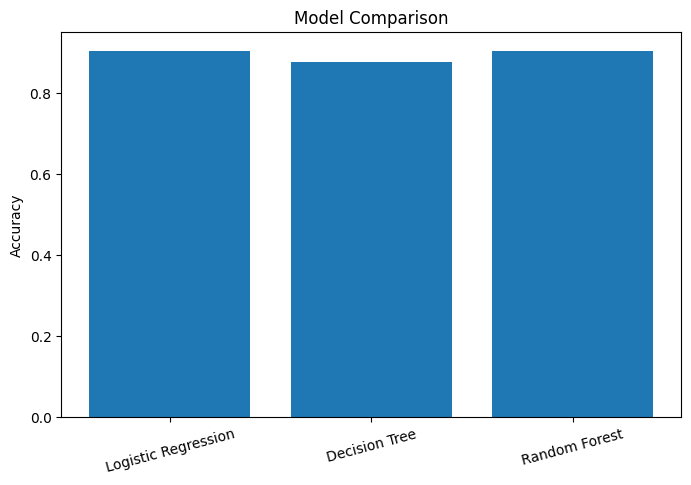

In [11]:
# Model Accuracy Visualization
model_names = [x[0] for x in results]
accuracies = [x[1] for x in results]

plt.figure(figsize=(8,5))
plt.bar(model_names, accuracies)
plt.title("Model Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=15)
plt.show()